# Lab 3
## Abdulaziz Saqer BinRuqush - 2230007229

### Environment Setup
This cell installs any missing packages. It is safe in both local Jupyter and Google Colab.


In [1]:
import importlib
import subprocess
import sys
from pathlib import Path

local_site = Path('.pydeps')
local_site.mkdir(exist_ok=True)
local_site_str = str(local_site.resolve())
if local_site_str not in sys.path:
    # Keep base environment first to avoid ABI mismatch for preinstalled compiled packages.
    sys.path.append(local_site_str)


def ensure_module(module_name, install_specs):
    try:
        module = importlib.import_module(module_name)
        print(f'{module_name} already available.')
        return module
    except Exception as exc:
        print(f'Installing {module_name} ({exc.__class__.__name__}).')

    cmd = [
        sys.executable,
        '-m',
        'pip',
        'install',
        '--upgrade',
        '--target',
        local_site_str,
        *install_specs,
    ]
    subprocess.check_call(cmd)
    importlib.invalidate_caches()
    return importlib.import_module(module_name)


# Ensure core scientific stack from base env
importlib.import_module('numpy')
importlib.import_module('matplotlib')
importlib.import_module('PIL')

# Install only packages missing from base env into local folder with NumPy<2 compatibility.
ensure_module('cv2', ['opencv-python-headless==4.10.0.84', 'numpy<2'])
ensure_module('skimage', ['scikit-image==0.22.0', 'numpy<2'])

print('Dependency check complete.')


Installing cv2 (ModuleNotFoundError).


Installing skimage (ModuleNotFoundError).


Dependency check complete.


### Path and Utility Helpers
These helpers make the notebook run on both local Jupyter and Google Colab.


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data, exposure


def is_colab():
    return Path('/content').exists()


def find_images_dir():
    candidates = []
    if is_colab():
        candidates.extend([
            Path('/content/Images'),
            Path('/content/Labs/Images')
        ])
    cwd = Path.cwd()
    candidates.extend([
        cwd / 'Images',
        cwd.parent / 'Images'
    ])
    for p in candidates:
        if p.exists():
            return p
    return None


IMAGES_DIR = find_images_dir()
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
print(f'Colab runtime: {is_colab()}')
print(f'Images dir: {IMAGES_DIR}')
print(f'Output dir: {OUTPUT_DIR.resolve()}')


def show_images(images, titles, cmap=None, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, len(images), i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap if cmap else 'gray')
        else:
            plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def to_rgb(image_bgr):
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def load_color_image_fallback():
    if IMAGES_DIR is not None:
        for name in ['Parrot.png', 'parrot.png', 'input.jpg', 'input.png', 'lena_grayscale_image.jpg']:
            p = IMAGES_DIR / name
            if p.exists():
                img = cv2.imread(str(p), cv2.IMREAD_COLOR)
                if img is not None:
                    print(f'Loaded local image: {p}')
                    return img
    print('Using skimage.data.astronaut() as fallback color image.')
    astro_rgb = data.astronaut()
    return cv2.cvtColor(astro_rgb, cv2.COLOR_RGB2BGR)


def load_gray_image_fallback():
    if IMAGES_DIR is not None:
        for name in ['cameraman.jpg', 'lena_grayscale_image.jpg', 'input.jpg', 'input.png']:
            p = IMAGES_DIR / name
            if p.exists():
                img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    print(f'Loaded local grayscale image: {p}')
                    return img
    print('Using skimage.data.camera() as fallback grayscale image.')
    cam = data.camera()
    return cam.astype(np.uint8)


Colab runtime: False
Images dir: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\Images
Output dir: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\outputs


## Procedural Steps

### Step 1: Read an image using OpenCV

Loaded local image: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\Images\lena_grayscale_image.jpg
Image shape: (148, 185, 3)


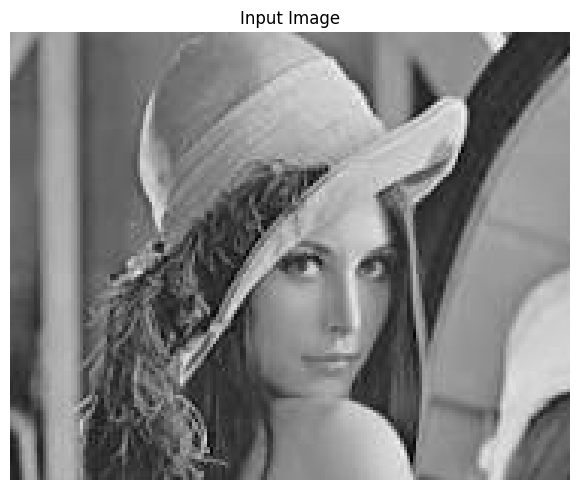

In [3]:
img_bgr = load_color_image_fallback()
img_rgb = to_rgb(img_bgr)
print('Image shape:', img_bgr.shape)
show_images([img_rgb], ['Input Image'])


### Step 2: Load an image in grayscale mode

Grayscale shape: (148, 185)


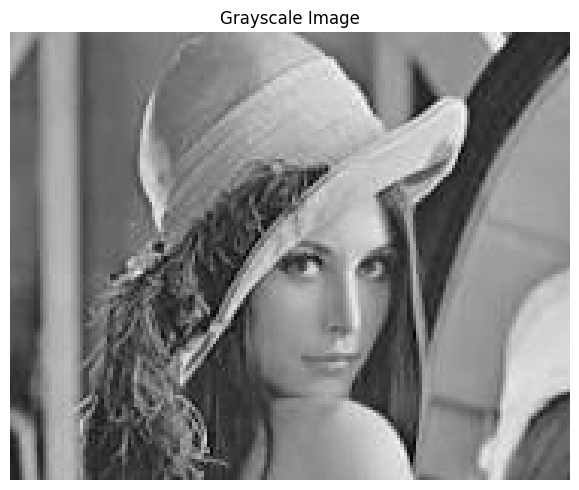

In [4]:
gray_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
print('Grayscale shape:', gray_img.shape)
show_images([gray_img], ['Grayscale Image'], cmap='gray')


### Step 3: Save an image

In [5]:
saved_path = OUTPUT_DIR / 'lab3_gray_output.jpg'
cv2.imwrite(str(saved_path), gray_img)
print(f'Saved grayscale image to: {saved_path.resolve()}')


Saved grayscale image to: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\outputs\lab3_gray_output.jpg


### Step 4: Convert image to different color spaces

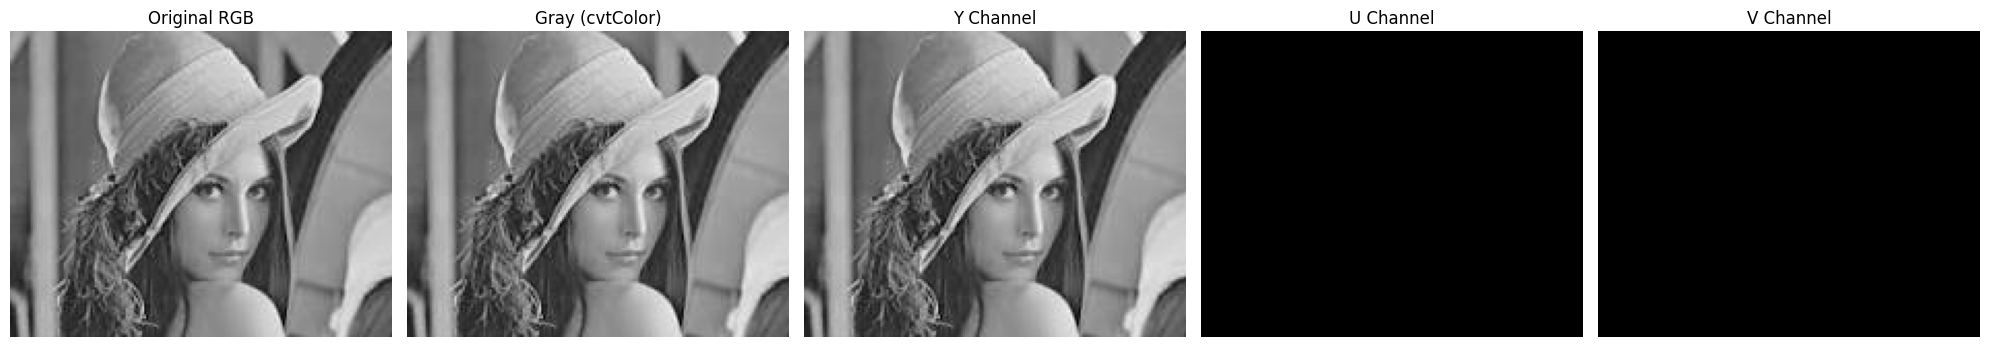

In [6]:
gray_from_cvt = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
yuv_img = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YUV)

y_channel = yuv_img[:, :, 0]
u_channel = yuv_img[:, :, 1]
v_channel = yuv_img[:, :, 2]

show_images(
    [to_rgb(img_bgr), gray_from_cvt, y_channel, u_channel, v_channel],
    ['Original RGB', 'Gray (cvtColor)', 'Y Channel', 'U Channel', 'V Channel'],
    cmap='gray',
    figsize=(20, 4)
)


## Assessment Tasks

### Task 1: Geometric Transformations

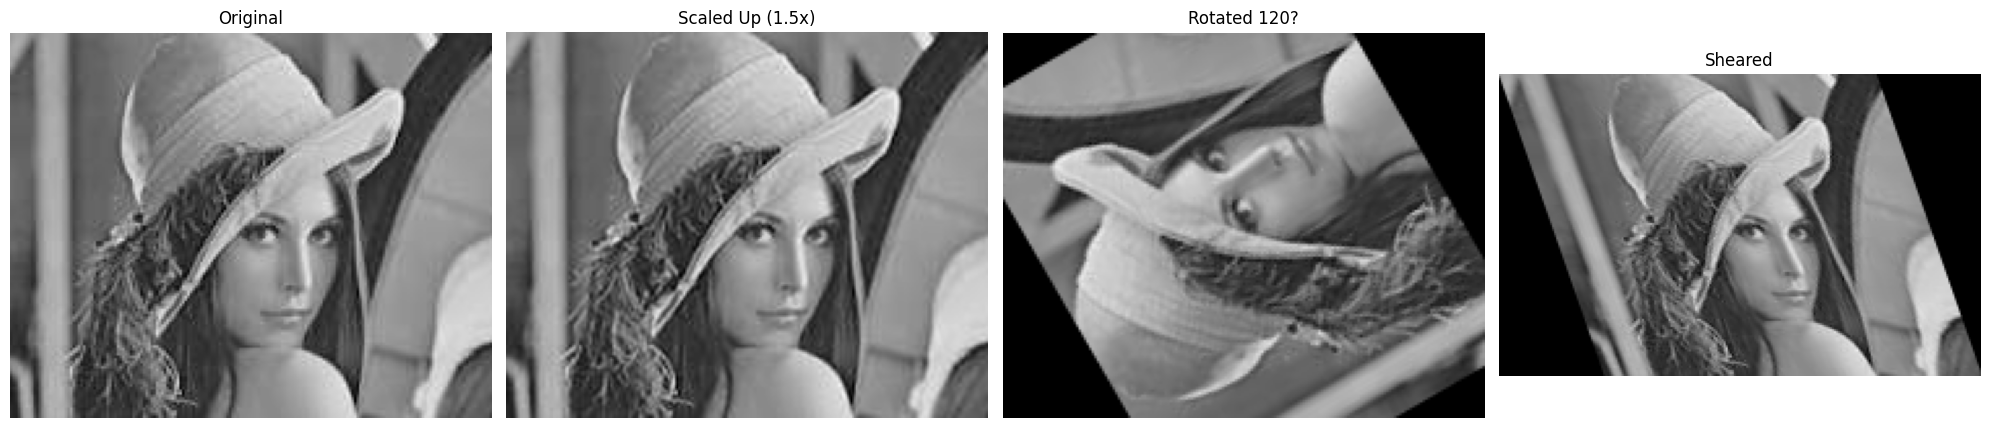

In [7]:
# 1) Increase image size
h, w = img_bgr.shape[:2]
scaled_up = cv2.resize(img_bgr, (int(w * 1.5), int(h * 1.5)), interpolation=cv2.INTER_CUBIC)

# 2) Rotate image by 120 degrees around center
center = (w // 2, h // 2)
rot_mat = cv2.getRotationMatrix2D(center, 120, 1.0)
rotated_120 = cv2.warpAffine(img_bgr, rot_mat, (w, h))

# 3) Shear operation (x-shear)
shear_factor = 0.35
shear_mat = np.array([[1, shear_factor, 0],
                      [0, 1,            0]], dtype=np.float32)
new_w = int(w + abs(shear_factor) * h)
sheared = cv2.warpAffine(img_bgr, shear_mat, (new_w, h))

show_images(
    [to_rgb(img_bgr), to_rgb(scaled_up), to_rgb(rotated_120), to_rgb(sheared)],
    ['Original', 'Scaled Up (1.5x)', 'Rotated 120?', 'Sheared'],
    figsize=(20, 5)
)


### Task 2: Intensity Transformations

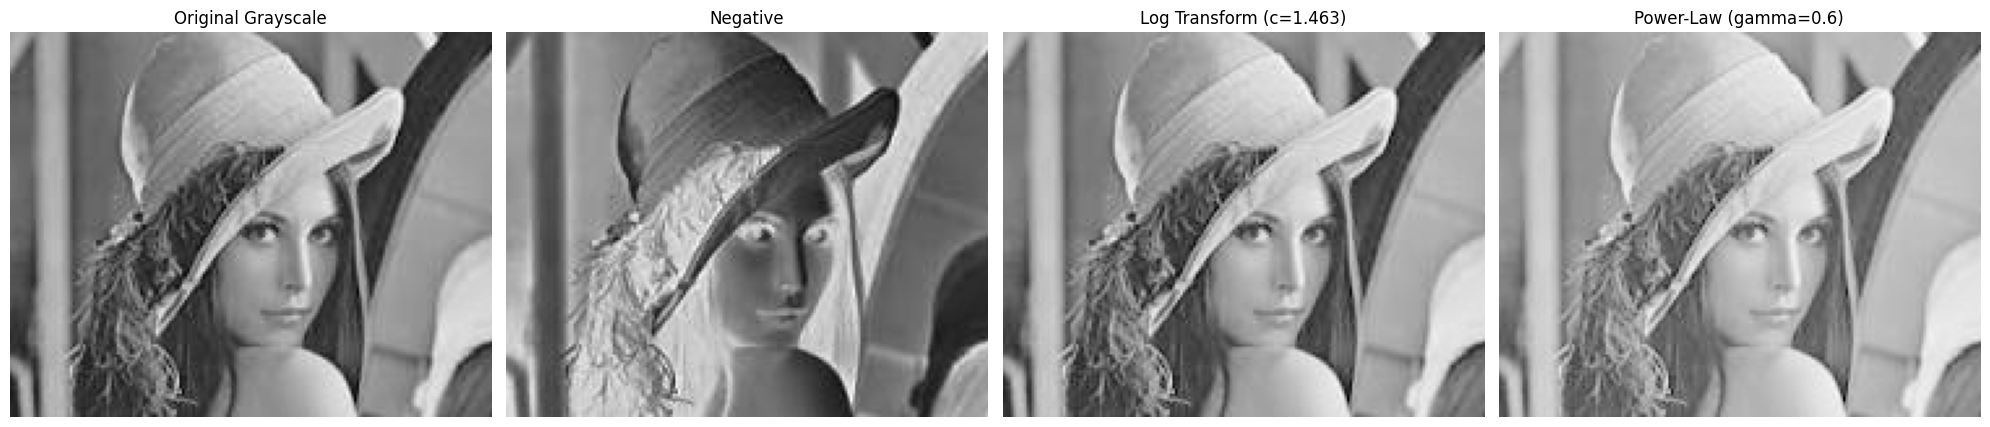

In [8]:
gray_float = gray_img.astype(np.float32) / 255.0

# 1) Negative
negative = 1.0 - gray_float

# 2) Log transformation
c = 1.0 / np.log1p(np.max(gray_float))
log_transformed = c * np.log1p(gray_float)

# 3) Power-law (gamma < 1 increases contrast in dark regions)
gamma = 0.6
power_law = np.power(gray_float, gamma)

show_images(
    [gray_float, negative, log_transformed, power_law],
    [
        'Original Grayscale',
        'Negative',
        f'Log Transform (c={c:.3f})',
        f'Power-Law (gamma={gamma})'
    ],
    cmap='gray',
    figsize=(20, 5)
)
